# Classificazione di frutti esotici

**TropicTaste Inc.**, leader nella distribuzione di frutti esotici, intende migliorare l'efficienza e l'accuratezza nel processo di classificazione dei frutti. L'obiettivo è sviluppare un modello di machine learning in grado di predire il tipo di frutto basandosi su caratteristiche numeriche.

## Obiettivi
Implementando un modello di classificazione automatizzato, TropicTaste Inc. potrà:
- **Migliorare l'Efficienza Operativa**: Automatizzare la classificazione ridurrà il tempo e le risorse necessarie, aumentando la produttività.
- **Ridurre gli Errori Umani**: Un modello di machine learning minimizzerà gli errori di classificazione, garantendo una maggiore precisione.
- **Ottimizzare l'Inventario**: Una classificazione accurata permetterà una migliore gestione dell'inventario, assicurando condizioni ottimali di conservazione per ogni tipo di frutto.
- **Aumentare la Soddisfazione del Cliente**: Una corretta identificazione e classificazione dei frutti contribuirà a mantenere elevati standard di qualità, migliorando la soddisfazione dei clienti.

## Requisiti del Progetto

### Preparazione del Dataset
- Caricamento e preprocessamento dei dati sui frutti esotici.
- Gestione di eventuali valori mancanti, normalizzazione e scalatura dei dati.

### Implementazione del Modello KNN
- Sviluppo e addestramento del modello KNN.
- Ottimizzazione dei parametri per migliorare l'accuratezza predittiva.

### Valutazione delle Performance
- Utilizzo di tecniche di validazione incrociata per valutare la capacità di generalizzazione del modello.
- Calcolo delle metriche di performance, come l'accuratezza e l'errore di classificazione.

### Visualizzazione dei Risultati
- Creazione di grafici per visualizzare e confrontare le performance del modello.
- Analisi e interpretazione dei risultati per identificare eventuali aree di miglioramento.

# Implementazione

Il progetto implementa un'analisi per **Tropic Taste, inc**, al fine di automatizzare e ottimizzare la classificazione dei frutti esotici che distribuisce, utilizzando modelli di classificazione con tecniche di regolarizzazione e cross-validation. Il tutto corredato da analisi e grafici a sostegno dei risultati

## Caricamento del dataset

Il dataset rappresenta un insieme di osservazioni di frutti esotici, tracciandone alcune features:

- **Frutto**: Il tipo di frutto. Questa è la variabile di destinazione (target) che vogliamo prevedere.
- **Peso (g)**: Il peso del frutto in grammi. Variabile continua.
- **Diametro medio (mm)**: Il diametro medio del frutto in millimetri. Variabile continua.
- **Lunghezza media (mm)**: La lunghezza media del frutto in millimetri. Variabile continua.
- **Durezza buccia (1-10)**: La durezza della buccia del frutto su una scala da 1 a 10. Variabile continua.
- **Dolcezza (1-10)**: La dolcezza del frutto su una scala da 1 a 10. Variabile continua.
- **Acidità (1-10)**: L'acidità del frutto su una scala da 1 a 10. Variabile continua.

Non potendo contare su una conoscenza di dominio specifica e non potendo effettuare ulteriori analisi preliminari sui dati, essi verranno gestiti direttamente come forniti. Di seguito carichiamo il dataset e ne mostriamo un estratto:

In [62]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

dataset = "https://proai-datasets.s3.eu-west-3.amazonaws.com/fruits.csv"

df = pd.read_csv(dataset)
df.head(5)

,Frutto,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
0,Mela,86.40,89.68,8.69,9.61,2.41
1,Mela,77.58,73.45,6.49,7.20,3.87
2,Mela,81.95,81.66,6.40,9.09,2.88
3,Mela,66.33,36.71,6.78,8.21,2.55
4,Mela,56.73,75.69,5.78,9.15,3.88


## Preprocessing dei dati

### Descrizione delle features

Analizziamo subito le features, valutando dati statistici e correlazione: questo ci consentirà di rimuovere dati poco informativi, ridurre la complessità del dataset, valutare le distribuzioni delle features, ottenendo possibili suggerimenti sulle trasformazioni che dovremo applicare.

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Frutto                 500 non-null    object 
 1   Peso (g)               500 non-null    float64
 2   Diametro medio (mm)    500 non-null    float64
 3   Lunghezza media (mm)   500 non-null    float64
 4   Durezza buccia (1-10)  500 non-null    float64
 5   Dolcezza (1-10)        500 non-null    float64
dtypes: float64(5), object(1)
memory usage: 23.6+ KB


### Verifica di valori mancanti

In [64]:
df.isna().sum()

Frutto                   0
Peso (g)                 0
Diametro medio (mm)      0
Lunghezza media (mm)     0
Durezza buccia (1-10)    0
Dolcezza (1-10)          0
dtype: int64

Il dataset, come si evince dal risultato, non presenta valori mancanti, perciò possiamo procedere ulteriormente.

Prima di effettuare la verifica della correlazione, facciamo un passaggio di LabelEncoder della variabile target:

In [65]:
from sklearn.calibration import LabelEncoder

le = LabelEncoder()
df["Frutto"] = le.fit_transform(df["Frutto"])

E creiamo quindi la matrice di correlazione, con coefficiente di Pearson:

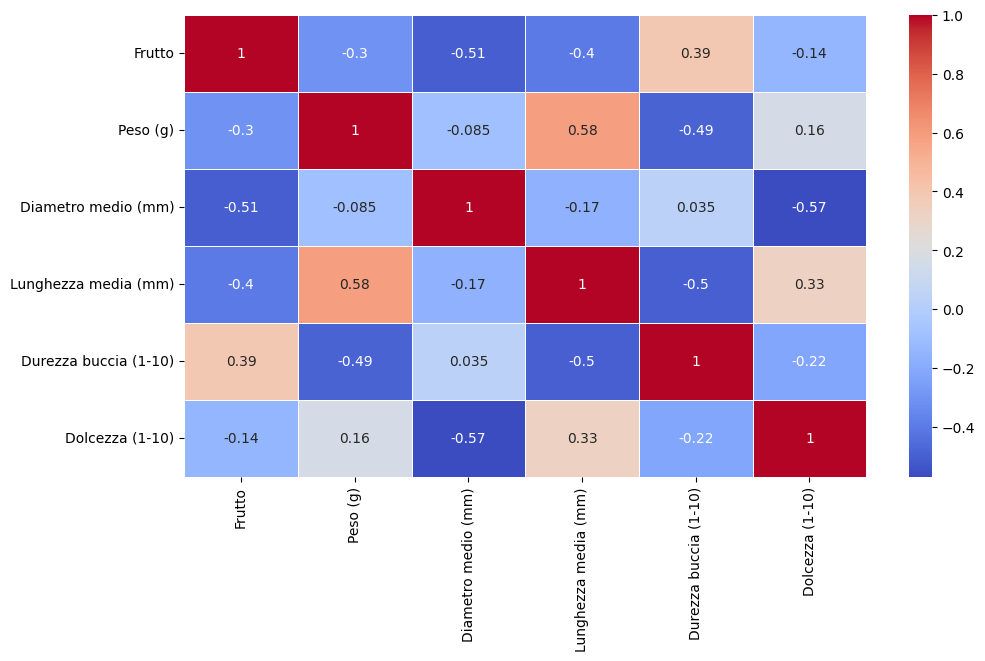

In [66]:
# Feature Correlation Analysis for numerical variables

plt.figure(figsize=(11, 6))

sns.heatmap(df.corr(method="pearson"), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

Dall'analisi della matrice sopra mostrata, le features sembrano avere quasi tutte un impatto quantomeno discreto sul target (si è scelto **0.10** come valore soglia). Inoltre, la correlazione tra features non presenta picchi tali da giustificare la rimozione di una di esse (con il treshold scelto di **0.75**) o l'applicazione di tecniche come la PCA.

### Verifica delle distribuzioni

Mostriamo ora una rappresentazione delle distribuzioni del target, per verificare se sono necessari interventi di regolarizzazione della distribuzione.

Defininiamo, innanzitutto, le funzioni di stampa dei grafici (boxplot, per verifica dell'IQR e dell'istogramma per la rappresentazione grafica della distribuzione):

In [67]:
#Boxplot for target distribution

def show_boxplot(feature, is_target=False):
    """
    Shows a boxplot for a given feature.

    Feature: the feature to analyze.
    """

    plt.figure(figsize=(10, 5))
    sns.boxplot(feature, orient="h", color="lightblue")

    if(is_target):
        plt.title("Distribuzione del target")
    else:
        plt.title(f"Distribuzione della feature {feature.name}")
        
    plt.show()

In [68]:
def show_histogram(feature):
    """
    Shows a histogram for a given feature.

    Feature: the feature to analyze.
    """

    plt.figure(figsize=(10, 5))
    sns.histplot(feature, bins=30, kde=True, color="lightblue")
    plt.title(f"Distribuzione della feature {feature.name}")
    plt.xlabel(feature.name)
    plt.ylabel("Frequenza")
    plt.show()

Calcoliamo i valori statistici:

In [69]:
df.describe()

,Frutto,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2.00000,47.313440,86.573100,5.298620,7.437640,3.593220
std,1.41563,26.768797,64.293403,2.641993,1.812548,1.264899
min,0.00000,8.570000,7.530000,1.150000,3.070000,1.250000
25%,1.00000,24.797500,50.510000,2.672500,6.152500,2.570000
50%,2.00000,42.380000,70.450000,5.670000,7.340000,3.535000
75%,3.00000,68.080000,88.852500,7.455000,8.615000,4.465000
max,4.00000,111.210000,299.890000,11.140000,13.720000,6.950000


E mostriamo ora tali grafici per il Target:

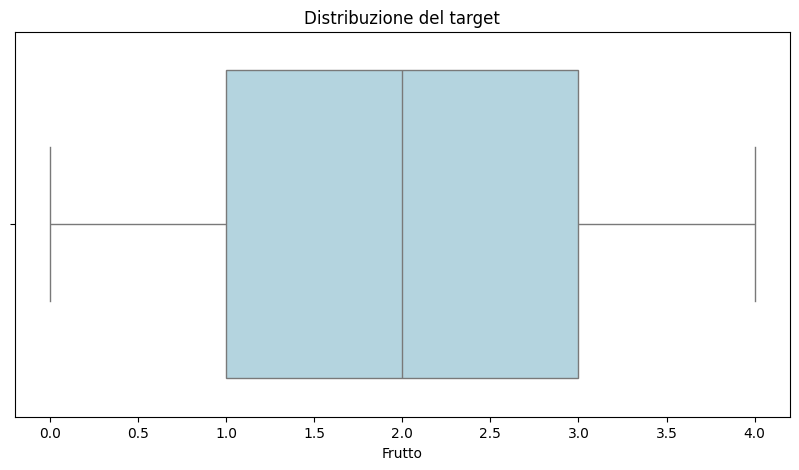

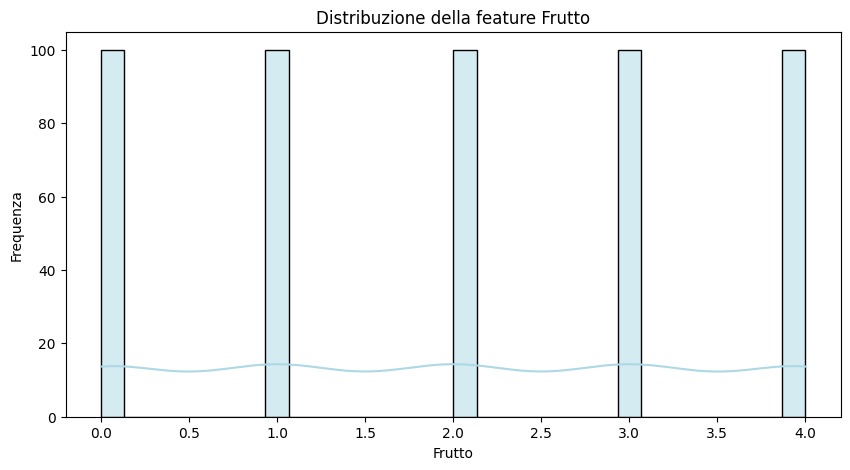

In [70]:
# Target distribution

y = df["Frutto"]

show_boxplot(y, is_target=True)
show_histogram(y)

I grafici mostrano (come deducibile anche dall'analisi delle metriche - df.describe()) che la distribuzione è perfettamente omogenea, con lo stesso numero di osservazioni per classe. Non sono quindi necessari passaggi di tecniche di generazione di sample sintetici come lo SMOTE.

Mostriamo ora le distribuzioni per le features:

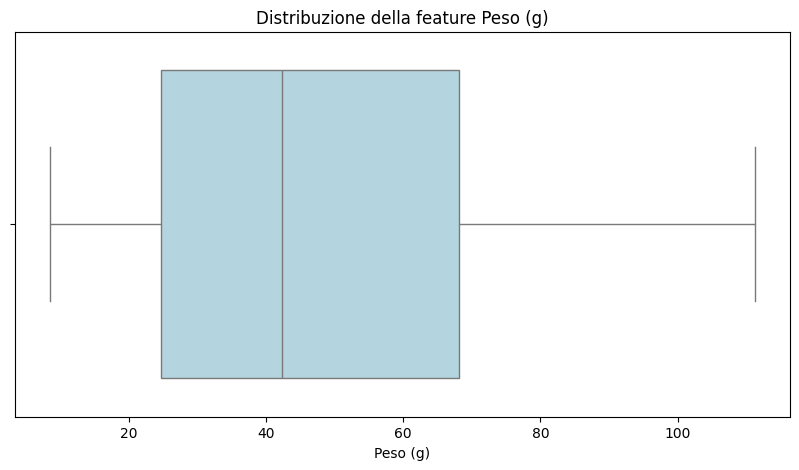

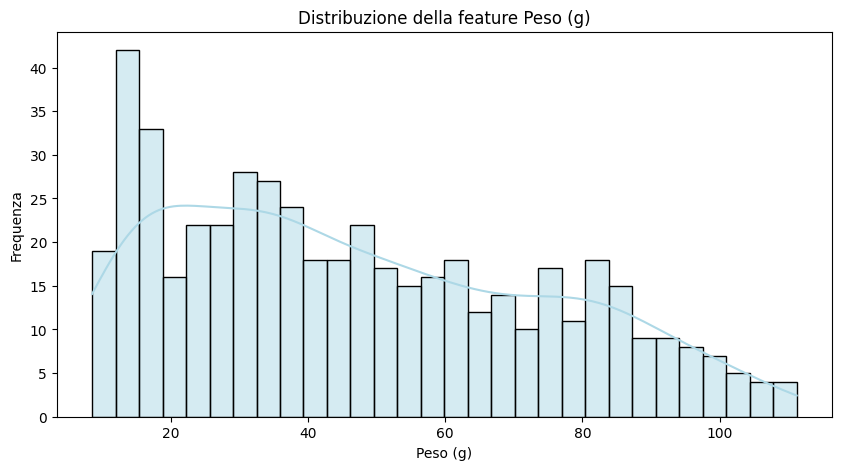

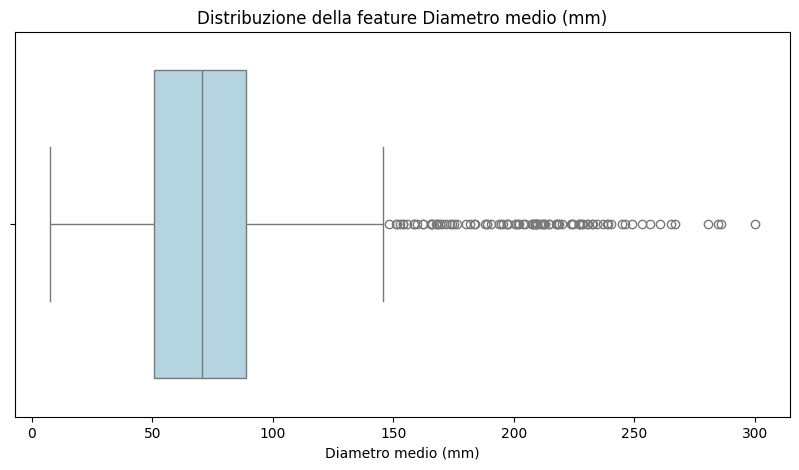

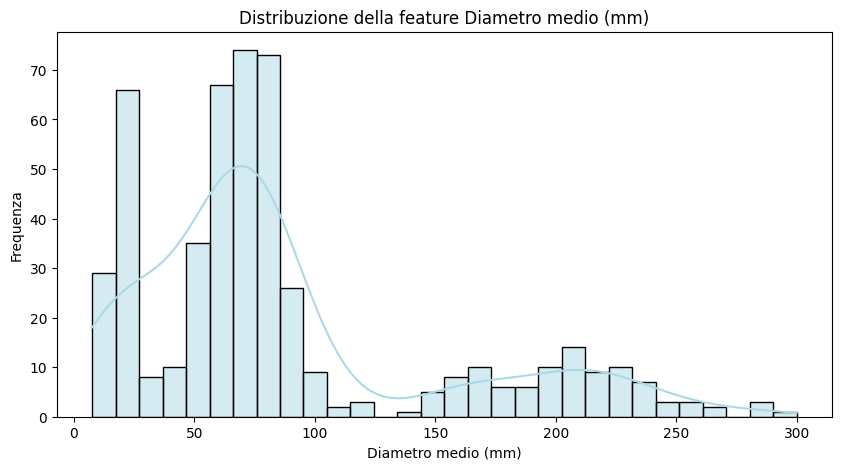

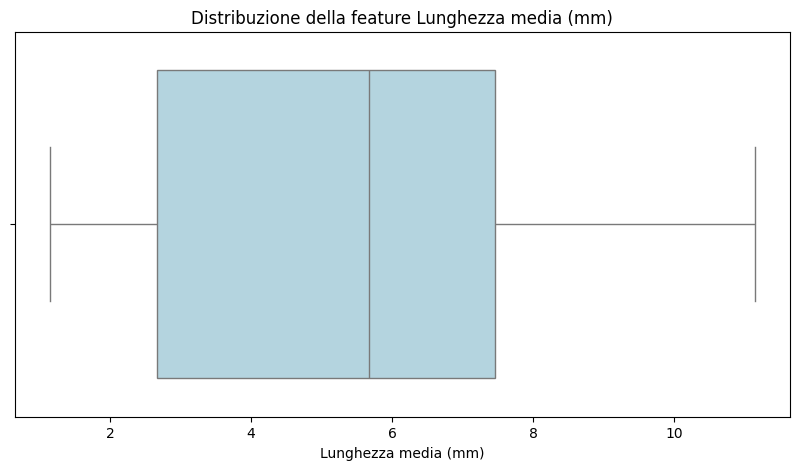

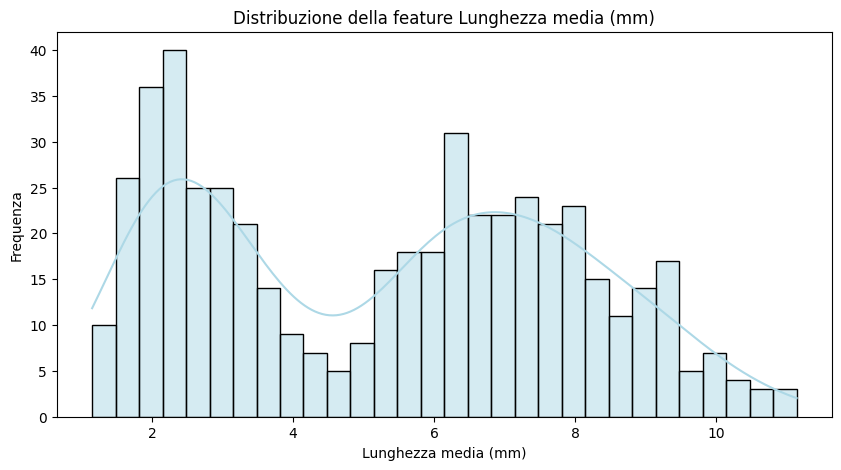

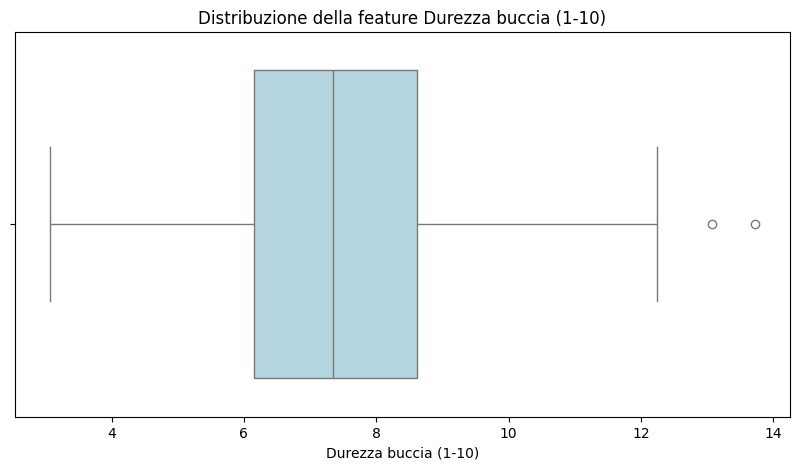

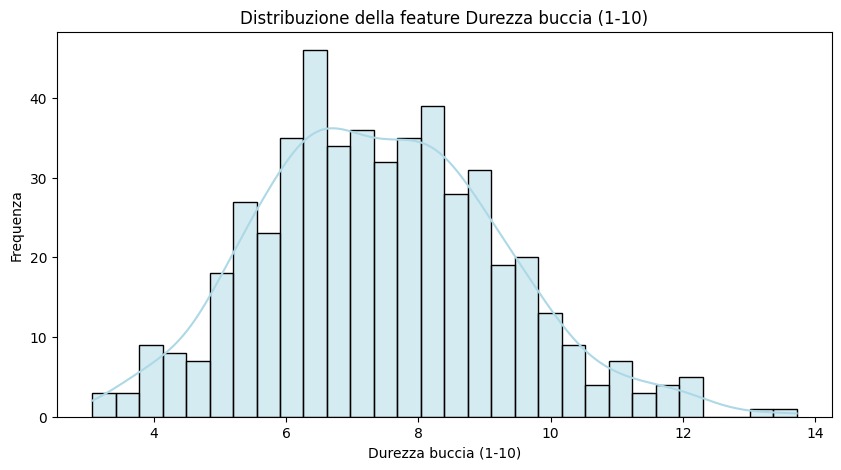

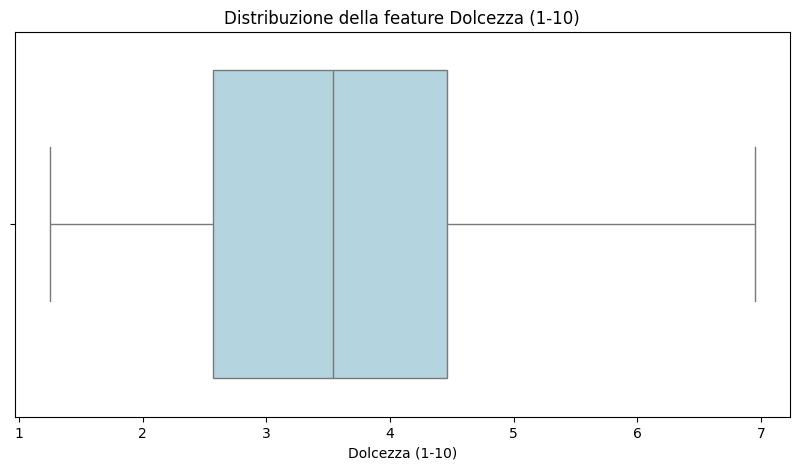

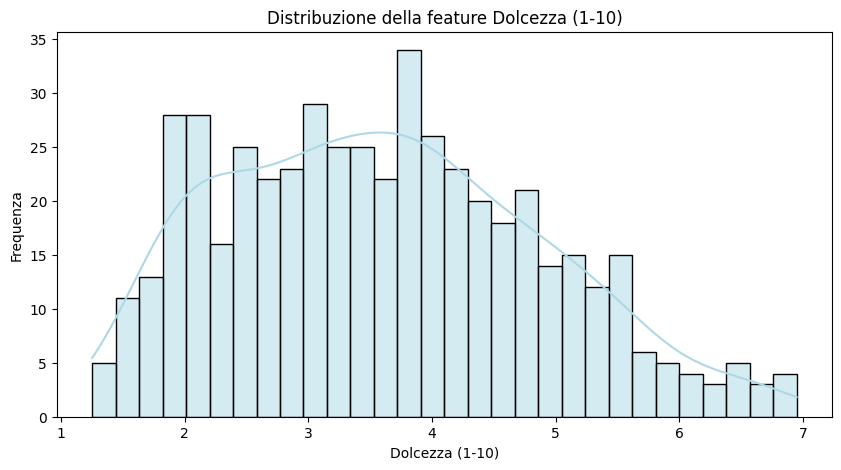

In [71]:
# Feature distribution analysis

X = df.drop(columns=["Frutto"])

for feature in X.columns:
    if feature == "Frutto":
        continue

    show_boxplot(X[feature])
    show_histogram(X[feature])

In questo caso, abbiamo la feature **Diametro Medio** con distribuzione positivamente asimmetrica e elevata deviazione standard.

Applicheremo alla feature la trasformazione *Logaritmo* per ridurla, dato che il modello KNN che addestreremo è sensibile agli outliers. Da alcuni test effettuati, performa meglio della radice quadrata e del RobustScaler.

In [72]:
# Log transformation for skewed features

def log_transform(features):
    """
    Applies log transformation to a feature in the dataframe.

    feature: the features to transform.
    """

    return np.log1p(features)

def inverse_log_transform(features):
    """
    Applies inverse log transformation to a feature in the dataframe.

    feature: the features to transform.
    """

    return np.expm1(features)

In [73]:
X["Diametro medio (mm)"] = log_transform(X["Diametro medio (mm)"])

**Lunghezza Media**, nonostante anch'essa presenti un'asimmetria, non verrà comunque modificata ulteriormente (ad eccezione dello scaling, che verrà applicato successivamente). Le altre features, infine, sembrano già sufficientemente bilanciate.

### Scaling delle features

Effettuiamo lo scaling delle features, necessario a supporto delle simmetrie delle distribuzioni e per l'ottimizzazione della scala di valori per il modello KNN. Qui istanziamo il trasformatore, lo scaling verrà fatto durante le tecniche di cross validation successivamente.

In [74]:
from sklearn.preprocessing import StandardScaler # type: ignore

ss = StandardScaler()

### Analisi delle variabili categoriche

Come già visualizzato in precedenza, le features sono solamente esclusivamente numerici. Non risultano necessarie quindi trasformazioni di variabili categoriche come il One-Hot Encoding o il Label Encoding.

Il dataset è così pronto per essere dato in pasto ai modelli KNN, che sono oggetto della sezione successiva.

## Addestramento del modello KNN

Verranno ora create e testate le varie configurazioni dell'estimatore KNN di Scikit-Learn. Iniziamo con l'importare le classi:

In [75]:
from sklearn.neighbors import KNeighborsClassifier # type: ignore
from sklearn.model_selection import GridSearchCV

E definiamo una griglia di parametri per l'ottimizzazione degli iperparametri:

In [76]:
#let's create a gridsearchcv to find the best parameters for the knn classifier

param_grid = {
    'n_neighbors': np.arange(1, 20, 2),
    'p': [1, 2],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': np.arange(10, 50, 10)
}

### Funzioni di validazione e calcolo performance

Definiamo ora le funzioni di cross-validation e di valutazione, per confrontare le varie configurazioni del modello KNN con differenti iperparametri:

In [ ]:
# Model Performances

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report

def evaluate_model(model, dataset, message=None, verbose=True):
    """
    Evaluates a model by computing its metrics.

    Model: the model to evaluate, already fitted.
    Dataset: the dataset to evaluate the model on.
    Message: a message to print before the evaluation.
    Squared: if True, the target values are squared before the evaluation.
    """
    X, y = dataset

    y_pred = model.predict(X)

    precision = precision_score(y, y_pred, average='weighted')
    recall = recall_score(y, y_pred, average='weighted')
    f1 = f1_score(y, y_pred, average='weighted')
    accuracy = accuracy_score(y, y_pred, average='weighted')
    
    if verbose:
        if message:
            print(message)

        # Computing the classification report and confusion matrix

        report = classification_report(y, y_pred)
        confusion = confusion_matrix(y, y_pred)

        # Printing results

        print(report)
        print(confusion)

        print("\n")

        print("Prime 5 classi reali:", y[:5].round(2))
        print("Prime 5 classi predette:", y_pred[:5].round(2))

        print("\n")

        print("------------------------------\n")

    return precision, recall, f1, accuracy

In [78]:
# Cross validation
from sklearn.model_selection import KFold

def cross_validation(model, dataset, cv=5, verbose=False):

    """
    Performs cross validation on the dataset.

    dataset: the dataset to evaluate the model on (features and target, passed as tuple).
    Model: the model to evaluate, will be fitted.
    Cv: the number of folds.
    """

    kf = KFold(n_splits=cv, shuffle=True)

    X, Y = dataset

    train_precision = []
    train_recall = []
    train_f1 = []
    train_accuracy = []

    test_precision = []
    test_recall = []
    test_f1 = []
    test_accuracy = []

    if isinstance(X, pd.DataFrame) or isinstance(X, pd.Series):
        X = X.values

    if isinstance(Y, pd.DataFrame) or isinstance(Y, pd.Series):
        Y = Y.values

    for train_index, test_index in kf.split(X):

        #Splitting the dataset into train and test sets
        X_train_split, X_test_split = X[train_index], X[test_index]
        Y_train_split, Y_test_split = Y[train_index], Y[test_index]
        
        #Feature Scaling
        X_train_split = ss.fit_transform(X_train_split)
        X_test_split = ss.transform(X_test_split)

        #Model fit with GridSearchCV
        
        model.fit(X_train_split, Y_train_split)

        if verbose:
            print(f"Fitting model with parameters: {model.get_params()}\n")
            print("-----------------------------\n")
            print("Best parameters:", model.best_params_)
            print("Best score:", model.best_score_)

        best_estimator = model.best_estimator_.fit(X_train_split, Y_train_split)

        #Model evaluation
        precision_train, recall_train, f1_train, accuracy_train = evaluate_model(
            best_estimator,
            (X_train_split, Y_train_split),
            message="Evaluation results on train set:\n",
        )

        precision_test, recall_test, f1_test, accuracy_test = evaluate_model(
            best_estimator,
            (X_test_split, Y_test_split),
            message="Evaluation results on test set:\n",
        )

        # Collecting results
        train_precision.append(precision_train)
        train_recall.append(recall_train)
        train_f1.append(f1_train)
        train_accuracy.append(accuracy_train)

        test_precision.append(precision_test)
        test_recall.append(recall_test)
        test_f1.append(f1_test)
        test_accuracy.append(accuracy_test)

    train_results = pd.DataFrame({
        'Precision': train_precision,
        'Recall': train_recall,
        'F1': train_f1,
        'Accuracy': train_accuracy
    })

    test_results = pd.DataFrame({
        'Precision': test_precision,
        'Recall': test_recall,
        'F1': test_f1,
        'Accuracy': test_accuracy
    })

    return train_results, test_results

### Cross Validation Split

Effettuiamo ora le validazioni incrociate di Cross Validation sul dataset. La funzione di prediction viene lasciata con le classi bilanciate, senza alterarne i pesi.

Di seguito viene istanziato l'oggetto GridSearch, per l'ottimizzazione degli iperparametri del KNN, e viene eseguito su diversi folds attraverso il metodo **cross_validation()**:

In [ ]:
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Cross validation with the best parameters
train_results, test_results = cross_validation(grid_search, (X, y), cv=5, verbose=True)

Fitting model with parameters: {'cv': 5, 'error_score': nan, 'estimator__algorithm': 'auto', 'estimator__leaf_size': 30, 'estimator__metric': 'minkowski', 'estimator__metric_params': None, 'estimator__n_jobs': None, 'estimator__n_neighbors': 5, 'estimator__p': 2, 'estimator__weights': 'uniform', 'estimator': KNeighborsClassifier(), 'n_jobs': -1, 'param_grid': {'n_neighbors': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]), 'p': [1, 2], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan'], 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'], 'leaf_size': array([10, 20, 30, 40])}, 'pre_dispatch': '2*n_jobs', 'refit': True, 'return_train_score': False, 'scoring': 'accuracy', 'verbose': 0}

-----------------------------

Best parameters: {'algorithm': 'auto', 'leaf_size': np.int64(10), 'metric': 'euclidean', 'n_neighbors': np.int64(3), 'p': 1, 'weights': 'distance'}
Best score: 0.93
Evaluation results on train set:

              precision    recall  f1-score   suppo

Mostriamo ora i risultati per ogni fold e calcoliamo i dati statistici su di essi, al fine di verificarne in particolare la media:

In [80]:
train_results.head(10)

,Precision,Recall,F1,Accuracy
0,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0


In [81]:
train_results.describe()

,Precision,Recall,F1,Accuracy
count,5.0,5.0,5.0,5.0
mean,1.0,1.0,1.0,1.0
std,0.0,0.0,0.0,0.0
min,1.0,1.0,1.0,1.0
25%,1.0,1.0,1.0,1.0
50%,1.0,1.0,1.0,1.0
75%,1.0,1.0,1.0,1.0
max,1.0,1.0,1.0,1.0


In [82]:
test_results.head(10)

,Precision,Recall,F1,Accuracy
0,0.900000,0.90,0.900000,0.90
1,0.941467,0.94,0.940068,0.94
2,0.933737,0.93,0.930638,0.93
3,0.962545,0.96,0.960481,0.96
4,0.928899,0.92,0.921114,0.92


In [83]:
test_results.describe()

,Precision,Recall,F1,Accuracy
count,5.000000,5.000000,5.000000,5.000000
mean,0.933330,0.930000,0.930460,0.930000
std,0.022641,0.022361,0.022410,0.022361
min,0.900000,0.900000,0.900000,0.900000
25%,0.928899,0.920000,0.921114,0.920000
50%,0.933737,0.930000,0.930638,0.930000
75%,0.941467,0.940000,0.940068,0.940000
max,0.962545,0.960000,0.960481,0.960000


### Hold-Out Split

E replichiamo, per completezza, i test anche su uno split di Hold-Out:

In [84]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Effettuiamo lo scaling:

In [85]:
# Feature Scaling
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

E riaddestriamo il GridSearch, per la ricerca dei migliori iperparametri del modello KNN:

In [190]:
# Hold Out tests

print("Testing model with Hold-Out split:\n")

grid_search.fit(X_train, y_train)

print("-------------------------------\n")
print("Best parameters:", grid_search.best_params_)
print(f"Best score: {grid_search.best_score_:.2f}", )
print("Best estimator:", grid_search.best_estimator_)
print("-------------------------------\n")

best_estimator = grid_search.best_estimator_.fit(X_train, y_train)

precision_train, recall_train, f1_train, accuracy_train = evaluate_model(
    best_estimator,
    (X_train, y_train),
    message="Train set evaluation"
)

precision_test, recall_test, f1_test, accuracy_test = evaluate_model(
    best_estimator,
    (X_test, y_test),
    message="Test set evaluation"
)

# Printing results
print("\n")

print("Train set metrics:")
print(f"Precision: {precision_train:.2f}")
print(f"Recall: {recall_train:.2f}")
print(f"F1: {f1_train:.2f}")
print(f"Accuracy: {accuracy_train:.2f}")

print("\n")

print("Test set metrics:")
print(f"Precision: {precision_test:.2f}")
print(f"Recall: {recall_test:.2f}")
print(f"F1: {f1_test:.2f}")
print(f"Accuracy: {accuracy_test:.2f}")
print("\n")

Testing model with Hold-Out split:

-------------------------------

Best parameters: {'algorithm': 'auto', 'leaf_size': np.int64(10), 'metric': 'manhattan', 'n_neighbors': np.int64(7), 'p': 1, 'weights': 'distance'}
Best score: 0.93
Best estimator: KNeighborsClassifier(leaf_size=np.int64(10), metric='manhattan',
                     n_neighbors=np.int64(7), p=1, weights='distance')
-------------------------------

Train set evaluation
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        81
           2       1.00      1.00      1.00        80
           3       1.00      1.00      1.00        83
           4       1.00      1.00      1.00        76

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

[[80  0  0  0  0]
 [ 0 81  0  0  0]
 [ 0  0 80  0  0]
 [ 0  0  0 83  0]

Lo split hold out mostra metriche tutte ad 1 per il train set, suggerendo overfitting. Verranno quindi considerati i valori del cross-validation per elaborare la configurazione migliore per il modello.

### Configurazione migliore per il KNN

I risultati ottenuti dalla cross validation concordano sulla configurazione migliore del modello, che verrà riaddestrato sull'intero dataset:

In [87]:
final_model = KNeighborsClassifier(algorithm='auto', leaf_size=10, metric='euclidean', n_neighbors=19, p=1, weights='uniform')

In [ ]:
#Feature Scaling
X = ss.fit_transform(X)

#Model fit
final_model.fit(X, y)

#Model prediction
y_pred = final_model.predict(X)

## Visualizzazione dei risultati

Calcoliamo ora i risultati, mostrando il report di classificazione (con le varie metriche) e la matrice di confusione:

In [120]:
report = classification_report(y, y_pred, output_dict=True)

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.85      0.86       100
           1       1.00      1.00      1.00       100
           2       0.87      0.91      0.89       100
           3       0.95      0.93      0.94       100
           4       1.00      1.00      1.00       100

    accuracy                           0.94       500
   macro avg       0.94      0.94      0.94       500
weighted avg       0.94      0.94      0.94       500



In [187]:
# Plot Confusion Matrix

def plot_cm(y, y_pred):
    """
    Plots the confusion matrix for the model predictions.

    y: the true labels.
    y_pred: the predicted labels.
    """

    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(10, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - Modello {final_model}")
    plt.xlabel("Valori predetti")
    plt.ylabel("Valori reali")
    plt.show()

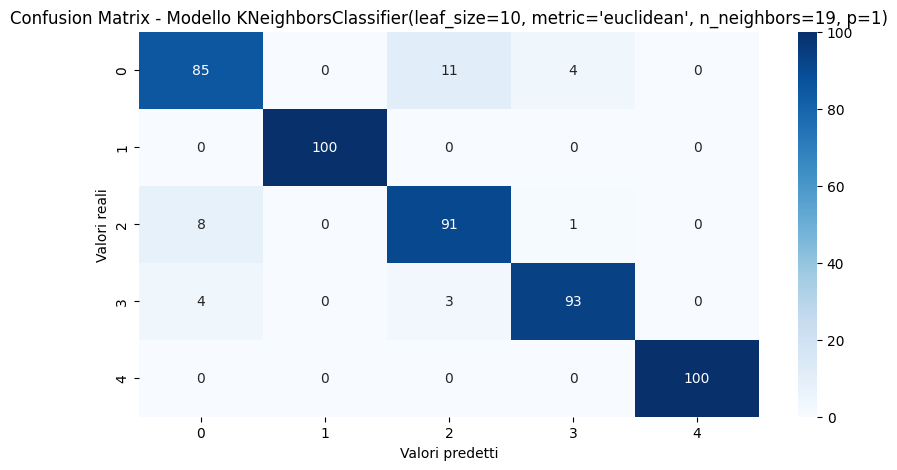

In [188]:
plot_cm(y, y_pred)

Il modello predice con un buon 94% di accuracy sul set di test, e dalla confusion matrix evinciamo che gli errori sono limitati e specifici a determinate classi, in particolare la 0 e la 2 (Peso e Lunghezza Media).

Definiamo, infine, una serie di funzioni per il plot dell'ROC, dell'AUC e delle metriche graficamente:

In [ ]:
#printing ROC Curve for each class with OvE method

from sklearn.calibration import label_binarize
from sklearn.metrics import auc, roc_curve

def plot_multiclass_roc(model, X_test, y_test, class_names):

    """
    Plots the ROC curve for a multiclass classification problem.

    Args:
        Model: the model to evaluate.
        X_test: the test features.
        y_test: the test labels.
        class_names: the names of the classes.
    """
    
    y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
    y_pred_proba = model.predict_proba(X_test)

    plt.figure(figsize=(10, 8))
    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Classe {class_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Scelta random')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - Modello {model}')
    plt.legend(loc='lower right')

    plt.grid()
    plt.show()


In [ ]:
# Plotting class metrics graphically

def class_metrics(report, class_names, metric="f1-score"):
    """
    Plots the metric each class based on the selected metric.

    Args:
        report: classification report as a dictionary (sklearn).
        class_names: list of class names.
        metric: the metric to use for importance (default is "f1-score").
    """
    importances = [report[class_name][metric] for class_name in class_names]
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=class_names, y=importances, hue=class_names, legend=False)
    
    # Values over bars
    for i, v in enumerate(importances):
        plt.text(i, v + 0.01, f"{v:.2f}", ha='center', va='bottom')

    plt.title(f"{metric} - Modello {final_model}")
    plt.xlabel("Classi")
    plt.ylabel(metric)
    
    plt.ylim(0, 1.1)
    plt.show()

In [148]:
# Learning Curve
from sklearn.model_selection import learning_curve

def show_learning_curve(model, dataset, cv=5):
    """
    Plots a learning curve for a given model.

    Model: the model to evaluate.
    Dataset: the dataset to evaluate the model on.
    Cv: the number of folds.
    """

    X, y = dataset

    train_sizes, train_scores, test_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=cv,
        scoring="accuracy"
    )

    plt.figure(figsize=(9, 4))

    plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Train scores")
    plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Test scores")

    plt.title(f"Learning curve - Modello {model}")

    plt.legend()

    plt.show()

E visualizziamone i rispettivi risultati:

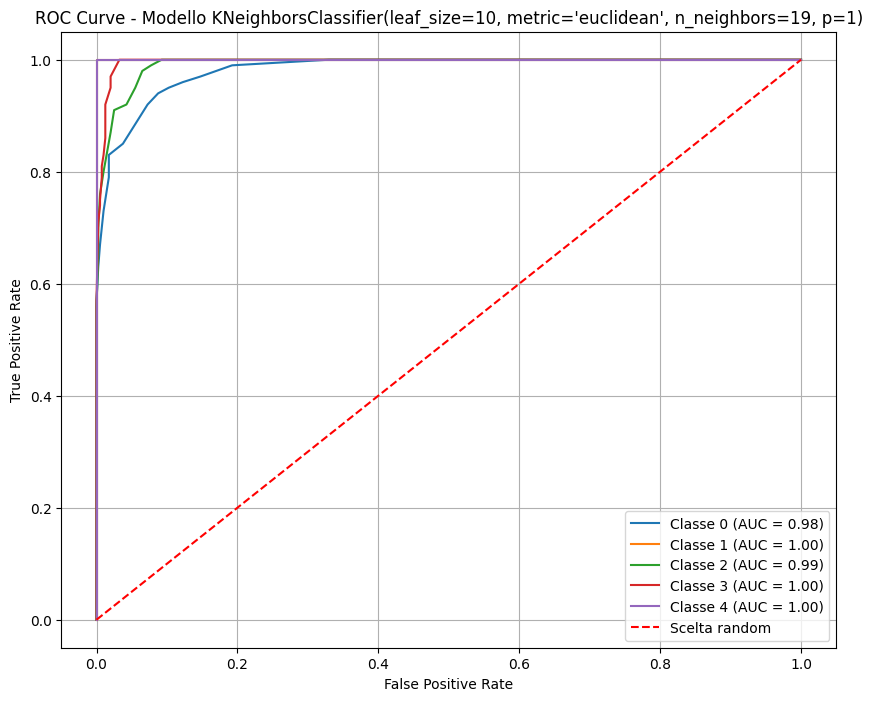

In [153]:
class_names = ['0','1', '2', '3', '4']
plot_multiclass_roc(final_model, X, y, class_names)

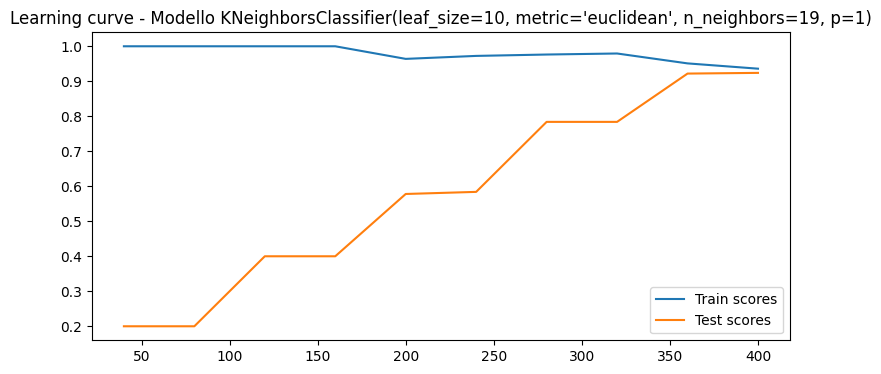

In [150]:
show_learning_curve(final_model, (X, y))

Visualizziamo inoltre tutte le metriche per ciascuna delle classi:

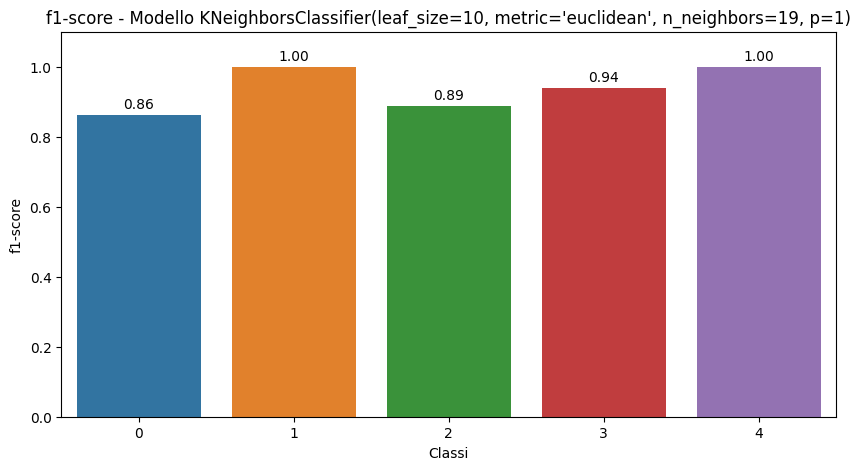

In [176]:
class_metrics(report, class_names, metric="f1-score")

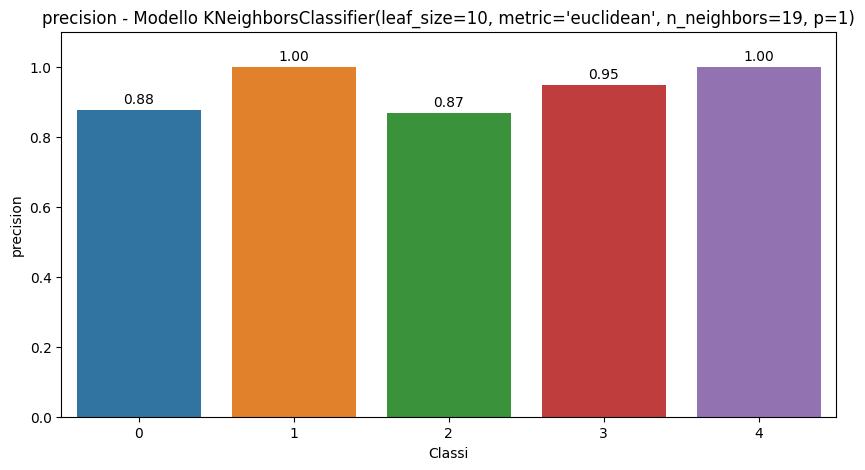

In [177]:
class_metrics(report, class_names, metric="precision")

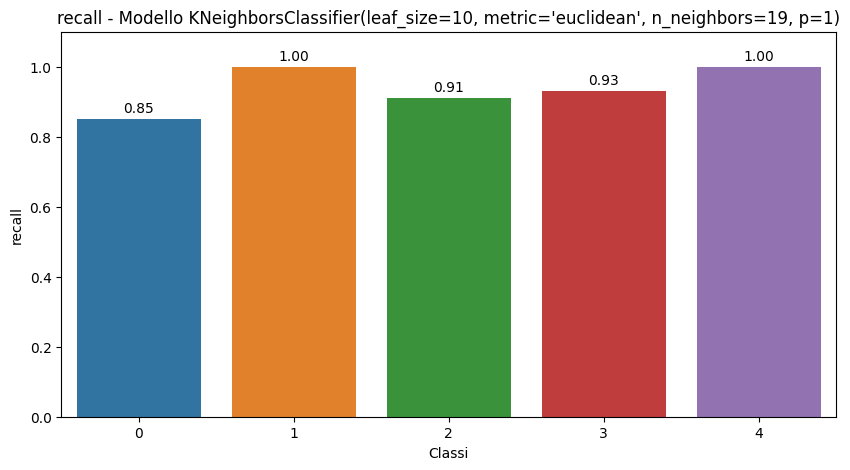

In [178]:
class_metrics(report, class_names, metric="recall")

## Conclusioni

Dalle rappresentazioni effettuate, evinciamo che:

* Secondo la learning curve, gli score sul set di training e di test tendono a valori simili (suggerendo l'assenza di overfitting/underfitting)
* Le classi sono predette con una confidenza maggiore dell'80%, secondo lo score F1;
* Osservando le metriche, notiamo che il modello cattura le relazioni tra le features efficacemente, e possiede buona capacità predittiva.

### Possibili aree di miglioramento

Per migliorare ulteriormente l'analisi, infine, è possibile:

* Confrontare i risultati del KNN con quelli di altri algoritmi (ad esempio, SVM, Random Forest) per verificare se il KNN è la scelta migliore per il problema in esame.

* Identificare i casi in cui il modello ha commesso errori e analizzarne le possibili cause (ad esempio, dati rumorosi, outlier, o limiti intrinseci del KNN).